In [3]:
import re
import numpy as np

def extract_numbers(text: str):
    """Return all numbers (as floats) found in the text."""
    return [float(x) for x in re.findall(r"\d+(?:\.\d+)?", text)]


def contains_close_number(text: str, target: float, rel_tol=0.2, abs_tol=1e-3):
    """
    Check if any number in the text is close to `target` within
    a relative tolerance (e.g. ±20%) or an absolute tiny tolerance.
    """
    nums = extract_numbers(text)
    for n in nums:
        if abs(n - target) <= max(abs_tol, rel_tol * abs(target if target != 0 else 1.0)):
            return True
    return False


def score_feedback(row, feedback: str) -> dict:
    """
    Heuristic scoring of a Granite feedback block for one trip.

    Returns values in [0,1] for:
      - accuracy_score
      - usefulness_score
      - clarity_score
      - Safety_score
      - overall_score
    """
    feedback_lower = feedback.lower()

    # ---------- 1. Accuracy: does it mention roughly the right numbers? ----------
    checks = []

    metrics = {
        "speed": row["Avg_Speed_kmh"],
        "rpm": row["Avg_RPM"],
        "fuel": row["Avg_Fuel_L/100km"],
        "high_rpm_pct": row["HighRPM_LowSpeed_%"],
        "idle_pct": row["Long_Idle_%"],
        "accel_events": row["Accel_Events"],
        "brake_events": row["Brake_Events"],
    }

    for label, val in metrics.items():
        try:
            if np.isfinite(val):
                checks.append(contains_close_number(feedback, float(val)))
        except Exception:
            # if anything breaks, treat as missing (False), not True
            checks.append(False)

    if checks:
        accuracy_score = sum(checks) / len(checks)   # proportion of metrics correctly referenced
    else:
        accuracy_score = 0.0   # if we couldn't check anything, be strict

    # ---------- 2. Usefulness: does it talk about the *right problems*? ----------
    usefulness_checks = []

    # If idling is high, feedback should talk about idling / waiting / traffic
    if row["Long_Idle_%"] > 30:
        usefulness_checks.append(
            any(word in feedback_lower for word in ["idle", "idling", "stationary", "traffic"])
        )

    # If accel/brake events are high, expect mentions of smooth driving
    if (row["Accel_Events"] + row["Brake_Events"]) > 300:
        usefulness_checks.append(
            any(w in feedback_lower for w in ["smooth", "accel", "brake", "gentle braking", "steady speed"])
        )

    # If RPM is high, expect mentions of rpm / gear / engine strain
    if row["Avg_RPM"] > 1500:
        usefulness_checks.append(
            any(w in feedback_lower for w in ["rpm", "gear", "engine strain", "over-revving"])
        )

    if usefulness_checks:
        usefulness_score = sum(usefulness_checks) / len(usefulness_checks)
    else:
        # if nothing to check (rare), fall back to medium
        usefulness_score = 0.5

    # ---------- 3. Clarity: structure + length ----------
    # - Some minimum length
    # - Contains bullets
    length_score = max(0.0, min(1.0, len(feedback.split()) / 150))  # 150 words → 1.0 cap
    bullet_score = 1.0 if re.search(r"^(\s*[-•])", feedback, flags=re.MULTILINE) else 0.3
    clarity_score = 0.5 * length_score + 0.5 * bullet_score

    # ---------- 4. Safety: very rough heuristic ----------
    unsafe_keywords = [
        "speed excessively",
        "ignore speed limits",
        "drive faster than",
        "tailgate",
        "drive aggressively",
        "overtake blindly",
    ]
    if any(k in feedback_lower for k in unsafe_keywords):
        Safety_score = 0.0
    else:
        Safety_score = 1.0

    # ---------- 5. Overall ----------
    overall_score = float(np.mean([accuracy_score, usefulness_score, clarity_score, Safety_score]))

    return {
        "accuracy_score": float(round(accuracy_score, 3)),
        "usefulness_score": float(round(usefulness_score, 3)),
        "clarity_score": float(round(clarity_score, 3)),
        "Safety_score": float(round(Safety_score, 3)),
        "overall_score": float(round(overall_score, 3)),
    }


Loaded 75 Granite feedback records


,Trip,feedback,prompt,accuracy_score,usefulness_score,clarity_score,Safety_score,overall_score
0,2017-07-10_Seat_Leon_KA_KA_Stau.csv,1. Overview:\nYour recent driving trip was cha...,Here is a driving trip summary:\n\n- Average s...,0.857,1.0,1.0,1.0,0.964
1,2017-07-11_Seat_Leon_KA_KA_Stau.csv,1. Overview: This driving trip summary shows a...,Here is a driving trip summary:\n\n- Average s...,0.857,1.0,1.0,1.0,0.964
2,2017-07-11_Seat_Leon_KA_S_Normal.csv,1. Overview:\nYour recent driving trip was qui...,Here is a driving trip summary:\n\n- Average s...,0.857,1.0,1.0,1.0,0.964
3,2017-07-11_Seat_Leon_S_RT_Frei.csv,1. Overview: Your recent driving trip was quit...,Here is a driving trip summary:\n\n- Average s...,0.857,1.0,1.0,1.0,0.964
4,2017-07-12_Seat_Leon_RT_S_Normal.csv,1. Overview: Your driving trip summary indicat...,Here is a driving trip summary:\n\n- Average s...,0.286,1.0,1.0,1.0,0.821
...,...,...,...,...,...,...,...,...
70,2018-03-26_Seat_Leon_RT_S_Normal.csv,1. Overview:\nYour driving trip was quite effi...,Here is a driving trip summary:\n\n- Average s...,0.286,1.0,1.0,1.0,0.821
71,2018-03-26_Seat_Leon_S_RT_Stau.csv,1. Overview:\nYour driving trip was characteri...,Here is a driving trip summary:\n\n- Average s...,0.714,1.0,1.0,1.0,0.929
72,2018-03-29_Seat_Leon_KA_RT_Stau.csv,1. Overview: Your recent driving trip was quit...,Here is a driving trip summary:\n\n- Average s...,0.714,1.0,1.0,1.0,0.929
73,2018-04-23_Seat_Leon_KA_KA_Frei.csv,1. Overview:\nYour driving trip summary indica...,Here is a driving trip summary:\n\n- Average s...,0.714,1.0,1.0,1.0,0.929



✅ Evaluated 75 trips.
💾 Saved JSON   → ../data/granite_feedback_evaluation.json
💾 Saved CSV    → ../data/granite_feedback_evaluation.csv


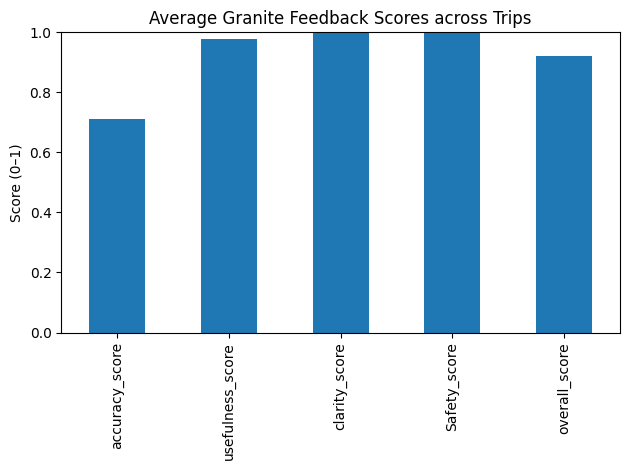

In [6]:
import json
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path

# --- Load trip summary (ground truth stats) ---
trip_summary_path = Path("../data/trip_summary_stats.csv")
trip_summary = pd.read_csv(trip_summary_path)

# For faster lookup, index by Trip
trip_summary_indexed = trip_summary.set_index("Trip")

# --- Load Granite feedback JSON ---
feedback_path = Path("../data/granite_trip_feedback.json")

with open(feedback_path, "r") as f:
    feedback_records = json.load(f)

print(f"Loaded {len(feedback_records)} Granite feedback records")

# --- Evaluate each feedback ---
evaluated = []

for rec in feedback_records:
    trip_name = rec.get("Trip")
    feedback_text = rec.get("feedback", "")

    if trip_name not in trip_summary_indexed.index:
        print(f"⚠️ Trip '{trip_name}' not found in trip_summary_stats.csv — skipping.")
        continue

    row = trip_summary_indexed.loc[trip_name]

    scores = score_feedback(row, feedback_text)

    evaluated.append({
        "Trip": trip_name,
        "feedback": feedback_text,
        "prompt": rec.get("prompt", ""),
        **scores,
    })


# --- Convert to DataFrame and inspect ---
eval_df = pd.DataFrame(evaluated)
display(eval_df)

print(f"\n✅ Evaluated {len(eval_df)} trips.")


# --- Save to JSON + CSV for later use / UI ---
out_json = Path("../data/granite_feedback_evaluation.json")
out_csv  = Path("../data/granite_feedback_evaluation.csv")

with open(out_json, "w") as f:
    json.dump(evaluated, f, indent=2)

eval_df.to_csv(out_csv, index=False)

print(f"💾 Saved JSON   → {out_json}")
print(f"💾 Saved CSV    → {out_csv}")

eval_df[["accuracy_score", "usefulness_score", "clarity_score", "Safety_score", "overall_score"]].mean().plot.bar()
plt.title("Average Granite Feedback Scores across Trips")
plt.ylabel("Score (0–1)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

